In [6]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal
from pydantic import BaseModel, Field
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage

load_dotenv()

True

In [5]:
# model
generator_llm = ChatGroq(model = "llama-3.1-8b-instant")
evaluator_llm = ChatGroq(model = "llama-3.3-70b-versatile")
optimizer_llm = ChatGroq(model = "llama-3.1-8b-instant")

In [9]:
class TweetState(TypedDict) :
    topic : str
    tweet : str
    evaluation : Literal['Approved', 'Need Improvement']
    feedback : str
    iterations : int
    max_iterations : int

In [10]:
def generate_post(state : TweetState):
    messages = [
        SystemMessage("You are a funny and clever Twitter/X influencer."),
        HumanMessage(f"""Write a short, original, and hilarious tweet on the topic: \"{state['topic']}\"
Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english""")
    ]
    
    ## llm 
    response = generator_llm.invoke(messages).content
    return {
        'tweet':response
    }

In [11]:
class EvaluateSchema(BaseModel) :
    evaluation : Literal['Approved', 'Need Improvement'] = Field(...,description= 'final evaluation result approved or not')
    feedback : str = Field(...,description= 'Constructive feedback for the tweet.')

def evaluate_post(state: TweetState):
    messages = [
        SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor,originality, virality, and tweet format."),
        HumanMessage(content= f"""
Evaluate the following Tweet : 
Tweet : {state['tweet']}
Use the criteria below to evaluate the tweet:
1. Originality — Is this fresh, or have you seen it a hundred times before?
2. Humor - Did it genuinely make you smile, laugh, or chuckle?
3. Punchiness - Is it short, sharp, and scroll-stopping?
4. Virality Potential - Would people retweet or share it?
5. Format — Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke,and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did... " or "What happens when."
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g.,"Masterpieces of the auntie-uncle universe" or vague summaries)

### Respond ONLY in structured format:
- evaluation:
"approved" or "needs _ improvement"
- feedback: One paragraph explaining the strengths and weaknesses
 """)
    ]
    
    # evaluate llm
    evaluator_llm_with_strct_output = evaluator_llm.with_structured_output(EvaluateSchema)
    response = evaluator_llm_with_strct_output.invoke(messages)
    return {
        'evaluation' : response.evaluation,
        'feedback' : response.feedback
    }

In [12]:
def optimize_post(state: TweetState):
    messages = [
        SystemMessage(f"""You are an elite, cynical ghostwriter for viral X (Twitter) accounts. Your job is to take a failed or mediocre tweet and rewrite it based on a critic's brutal feedback."""),
        HumanMessage(f"""
Study the "Original Tweet" and the "Critic Feedback" below. Deliver a highly polished, high-performance version.

### Rules for the Optimization:
- STRICTLY under 280 characters.
- NO question-and-answer formats (e.g., do not use "Why did..." or "What happens when...").
- NO traditional setup-punchline structures.
- NO generic, deflating, or weak summary lines at the end.
- It must be sharp, scroll-stopping, native to X culture, and highly shareable.

### Respond ONLY in this structured format:
- optimized_tweet:
"[Insert the newly rewritten tweet here]"

- improvements_made:
[One bullet point explaining exactly how you fixed the critic's main complaint]

---
Original Tweet: 
"{state['tweet']}"

Critic Feedback:
"{state['feedback']}"
""")]
    # optimize the llm 
    response = optimizer_llm.invoke(messages).content
    return {
        'iterations' : state['iterations'] + 1,
        'tweet' : response
    }

In [21]:
def check_evaluation(state:TweetState) -> Literal['Approved', "Need Improvement"]:
    if state['evaluation'] == 'Approved' or state['iterations']>=state['max_iterations'] :
        return 'Approved'
    else :
        return 'Need Improvement'

In [22]:
graph = StateGraph(TweetState)

graph.add_node("generate", generate_post)
graph.add_node("evaluate", evaluate_post)
graph.add_node("optimize", optimize_post)

In [23]:
graph.add_edge(START, 'generate')
graph.add_edge('generate', 'evaluate')
graph.add_conditional_edges('evaluate', check_evaluation, {'Approved':END, 'Need Improvement':'optimize'})
graph.add_edge('optimize', 'evaluate')

In [24]:
workflow = graph.compile()

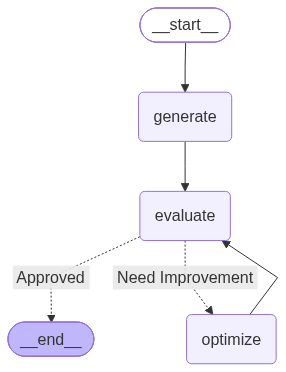

In [25]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [26]:
inital_state = {
    'topic' : "AI bubble",
    'iterations':1,
    'max_iterations':5
}
final_state = workflow.invoke(inital_state)

In [27]:
final_state

{'topic': 'AI bubble',
 'tweet': '"We\'re living in an AI bubble: where robots tell us what to do, Alexa judges our taste in music, and Siri gives us unsolicited life advice. Meanwhile, I\'m just over here trying to get Google Maps to not get me lost in my own neighborhood #AIBubble"',
 'evaluation': 'Approved',
 'feedback': "This tweet is a great example of a well-crafted joke that effectively utilizes the criteria for evaluation. The originality of the tweet is high, as it presents a fresh perspective on the AI bubble we're living in. The humor is also well-executed, as it pokes fun at the relatable struggle of dealing with AI assistants like Alexa, Siri, and Google Maps. The punchiness of the tweet is spot on, with a short and sharp message that is scroll-stopping. The virality potential is also high, as people can easily relate to the tweet and share it with others. Lastly, the format of the tweet is well-formed, with a clear and concise message that is under 280 characters and doe